# Quarter Circle with Void

In [1]:
# Change start method form 'fork' for clusters
import multiprocessing
multiprocessing.set_start_method('spawn')

import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad
import pandas as pd

from ttnte.xs.benchmarks import Server
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import gmres
from ttnte.cad import Patch
from ttnte.sources import IsotropicInternalSource
from mpl_toolkits.axes_grid1 import make_axes_locatable

tn.set_default_dtype(tn.float64)

## Define Cross Section Library and IGA Mesh

In [2]:
# Discretization
num_ordinates = 1024

# Get XS data
total = 1  # 1/cm
scattering_ratio = 0.9
xs_server = Server(
    {
        "Source": {
            "total": np.array([total]),
            "scatter_gtg": np.array([[[total * scattering_ratio]]]),
        },
        "Void": {
            "total": np.array([0]),
            "scatter_gtg": np.array([[[0]]]),
        },
    }
)

In [3]:
# Create quarter circle NURBS surface
radius = 5 # cm
pitch = 12 # cm
c0 = cad.circle(radius=radius, angle=np.pi / 2)
c1 = c0.slice(0, 0, 0.5)
c2 = c0.slice(0, 0.5, 1)
l0 = cad.line(p0=(0, 0), p1=(0, 0))

# Create water patch
l1 = cad.line(p0=(pitch / 2, 0), p1=(pitch / 2, pitch / 2))
l2 = cad.line(p0=(pitch / 2, pitch / 2), p1=(0, pitch / 2))

# Create NURBS surfaces
void = [Patch(cad.ruled(c1, l1), "Void"), Patch(cad.ruled(c2, l2), "Void")]
source = [Patch(cad.ruled(l0, c1), "Source"), Patch(cad.ruled(l0, c2), "Source")]

# Add uniform source of 1/cm to patch
source[0].set_source(IsotropicInternalSource(np.ones((1, *source[0].shape))))
source[1].set_source(IsotropicInternalSource(np.ones((1, *source[1].shape))))

# Initialize IGA mesh and add the patches
mesh = IGAMesh(max_processes=32)
for patch in void + source:
    mesh.add_patch(patch)

# Refine each patch to have 6 knot spans with degree 2
mesh.refine(9, 3)

# Connect patches
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_conditions(("left", "bottom"))

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=0, name=None, num_patches=4, reflective_boundaries=True)
  -> Patch(material=Void, source=None, id=0, name=None, shape=(12, 12), backend=geomdl)
  -> Patch(material=Void, source=None, id=1, name=None, shape=(12, 12), backend=geomdl)
  -> Patch(material=Source, source=IsotropicInternalSource, id=2, name=None, shape=(12, 12), backend=geomdl)
  -> Patch(material=Source, source=IsotropicInternalSource, id=3, name=None, shape=(12, 12), backend=geomdl)

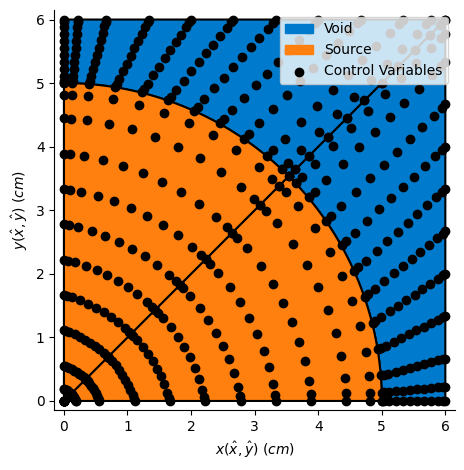

In [4]:
# Plot final mesh
ax = mesh.plot(plot_boundaries=True)
plt.tight_layout()
plt.savefig("./figs/quarter_circle.png", dpi=300, transparent=True)
plt.show()

## Assemble Matrix and TT Operators

In [5]:
# Create operators in COO format
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
mats = assembler.build()

# Save TT information
assembler.save_info("./coo_info.csv")

## Create operators in COO format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
    max_processes=2,
)
tts = assembler.build(use_tt=False, eps=1e-5, q=False)

# Save TT information
assembler.save_info("./tt_info.csv")

Running MatrixAssembler.build()
Discretization: N = 1024, G = 1, P = 4, A = 12, B = 12
Operators: H, S, q, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/4 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 12.44 s)
Step            Shape                     Compression
H               589824,589824                8079.78
B_out           589824,589824              213230.35
B_in            589824,589824              233510.34
S               589824,589824             1045249.11
q               589824                          1.00
Running TTAssembler.build()
Discretization: N = 1024, G = 1, P = 4, A = 12, B = 12
Operators: H, S, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/4 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 8.27 s)
Step            Ranks                     Compression
H               3,3,3,10,18               10339168.78
B_out           4,28,42,46,7               852510.17
B_in            6,30,44,47,7               747242.83
S               1,1,1,2,7                 97068178.29


## Solve

In [6]:
# Run fixed source calculation
psi = gmres(
    A=(tts.H - tts.S).round(1e-5) + (mats.B_out - mats.B_in).combine(),
    b=mats.q,
    tol=1e-6,
    gpu_idx=0,
    maxiter=1000,
    restart=100,
    callback_frequency=5,
)[0].reshape(assembler.discretization)

# Save solution
mesh.save(path="mesh.hdf5", solution=psi)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

Running batched GMRES on GPU 0


-- (5): |r| = 0.628579894349, |r|/|b| = 0.012985014093, Elapsed Time = 2.036 s


-- (10): |r| = 0.174171513584, |r|/|b| = 0.003597982657, Elapsed Time = 4.039 s


-- (15): |r| = 0.080368588635, |r|/|b| = 0.001660230092, Elapsed Time = 6.043 s


-- (20): |r| = 0.040152809972, |r|/|b| = 0.000829464652, Elapsed Time = 8.046 s


...

-- (340): |r| = 0.000054769275, |r|/|b| = 0.000001131407, Elapsed Time = 136.278 s


-- (345): |r| = 0.000052755922, |r|/|b| = 0.000001089816, Elapsed Time = 138.282 s


-- (350): |r| = 0.000050787149, |r|/|b| = 0.000001049146, Elapsed Time = 140.289 s


-- (355): |r| = 0.000048801479, |r|/|b| = 0.000001008126, Elapsed Time = 142.296 s


-- Converged!


In [7]:
leakage_frac_openmc = [0.43995486599999994, 2.2442114486922458e-05]
phi_mc = np.load("./openmc/data/mesh_flux.npy")
phi_mc_stdev = np.load("./openmc/data/mesh_stdev.npy")

leakage = assembler.outward_current(psi)
production = assembler.total_production()
leakage_frac = float(leakage / production)
print(f"TIDG leakage fraction = {leakage_frac}")
print(f"OpenMC leakage fraction = {leakage_frac_openmc[0]} +/- {leakage_frac_openmc[1]}")
print(f"Difference = {leakage_frac - leakage_frac_openmc[0]}")
print(f"TIDG is {(leakage_frac - leakage_frac_openmc[0]) / leakage_frac_openmc[1]} stdevs from OpenMC")

TIDG leakage fraction = 0.4399658720814657
OpenMC leakage fraction = 0.43995486599999994 +/- 2.2442114486922458e-05
Difference = 1.1006081465758655e-05
TIDG is 0.4904208768818176 stdevs from OpenMC


<Figure size 640x480 with 0 Axes>

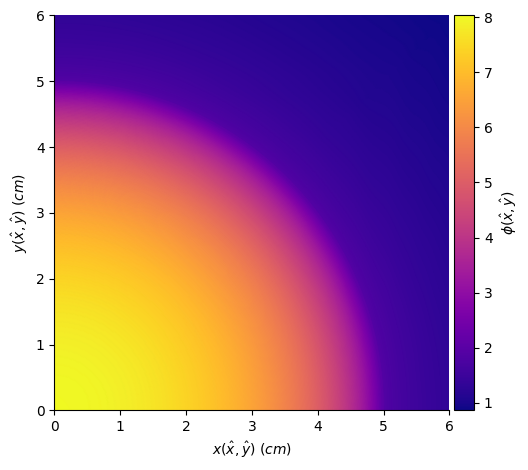

In [8]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(5, 5))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)

# Set control points
mesh.set_phi(phi[0,])

# Calculate regular mesh
phi_avg[0,] = mesh.regular_mesh(pids, coords)

# Plot
plt.clf()
ax, cbar = mesh.plot(plot_ctrlpts=False)
cbar.set_label(r"$\phi(\hat{x}, \hat{y})$")
plt.tight_layout()
plt.savefig("./figs/phi.png", dpi=300, transparent=True)
plt.show()

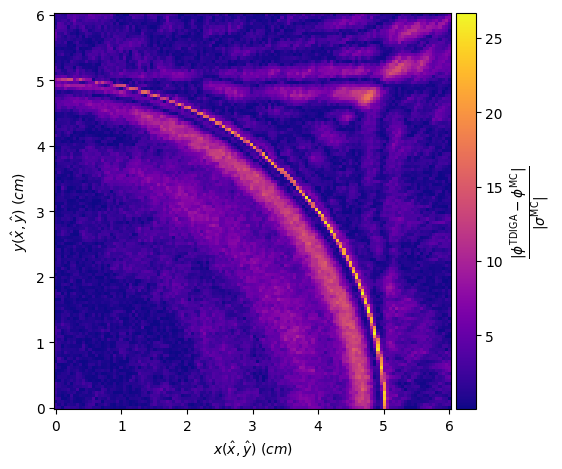

In [9]:
# Regular mesh
X, Y = np.meshgrid(
    np.linspace(0, 6, phi_mc.shape[1]),
    np.linspace(0, 6, phi_mc.shape[2]),
)

# Calculate z-score within each voxel
z = np.abs((phi_avg - phi_mc) / phi_mc_stdev)
stats = {
    "Group": list(range(1, xs_server.num_groups + 1)),
    **{
        name: np.zeros(xs_server.num_groups) 
        for name in 
        ["Minimum", "Q1", "Median", "Q2", "Maximum", "Mean", "L2 Error"]
    },
}
   
# Plot z-score
plt.clf()
ax = plt.gca()
cmesh = ax.pcolormesh(X, Y, z[0,], cmap="plasma")
divider = make_axes_locatable(ax)
cbar = plt.colorbar(
    cmesh,
    cax=divider.append_axes("right", size="5%", pad=0.05),
)
cbar.set_label(
    r"$\frac{|\phi^{\text{TDIGA}} - \phi^{\text{MC}}|}{|\sigma^{\text{MC}}|}$",
    size=14
)
ax.set_aspect("equal")
ax.set_xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
ax.set_ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
plt.tight_layout()
plt.savefig(f"./figs/phi_zscore.png", dpi=300, transparent=True)
plt.show()

# Get some stats
stats["Minimum"][0] = np.min(z[0,])
stats["Q1"][0] = np.percentile(z[0,], 25)
stats["Median"][0] = np.median(z[0,])
stats["Q2"][0] = np.percentile(z[0,], 75)
stats["Maximum"][0] = np.max(z[0,])
stats["Mean"][0] = np.mean(z[0,])

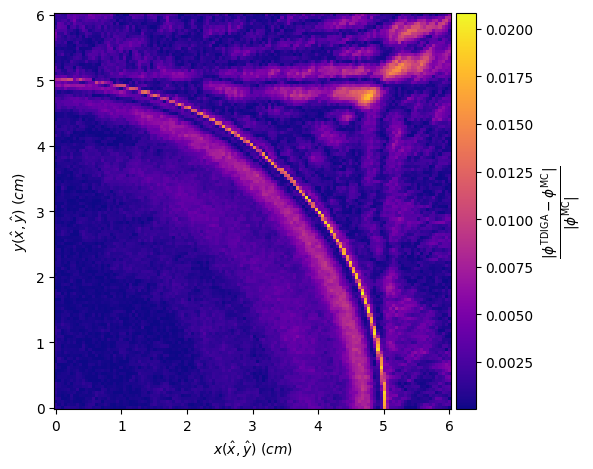

,Group,Minimum,Q1,Median,Q2,Maximum,Mean,L2 Error
0,1,0.000516,1.189332,2.610193,4.714002,26.679036,3.446078,0.002172


In [10]:
relative_error = np.abs((phi_avg - phi_mc) / phi_mc)
  
# Plot z-score
plt.clf()
ax = plt.gca()
cmesh = ax.pcolormesh(X, Y, relative_error[0,], cmap="plasma")
divider = make_axes_locatable(ax)
cbar = plt.colorbar(
    cmesh,
    cax=divider.append_axes("right", size="5%", pad=0.05),
)
cbar.set_label(
    r"$\frac{|\phi^{\text{TDIGA}} - \phi^{\text{MC}}|}{|\phi^{\text{MC}}|}$",
    size=14
)
ax.set_aspect("equal")
ax.set_xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
ax.set_ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
plt.tight_layout()
plt.savefig(f"./figs/phi_error.png", dpi=300, transparent=True)
plt.show()

# Calculate L2-error
stats["L2 Error"][0] = (
    np.linalg.norm((phi_avg[0,] - phi_mc[0,]).flatten(), 2) 
    / np.linalg.norm(phi_mc[0,].flatten(), 2)
)
pd.DataFrame(stats)